# ENTREGA FINAL - VISUALIZACIÓN OBJETIVO SECUNDARIO OS03
## OS03 – Prosperidad y desarrollo en Madrid. 
#### Caracterizar y explorar asociaciones entre exposición al ruido y desarrollo (nivel de ingresos).

El Objetivo Secundario 3 (OS03) prosperidad y desarrollo, consiste en explorar asociaciones descriptivas entre la exposición al ruido ambiental y variables de prosperidad económica, como el nivel de ingresos, utilizando datos agregados y representaciones comparativas. 

La visualización de OS03 explora de forma descriptiva la relación entre exposición al ruido y nivel de renta mediante datos agregados, facilitando la comparación entre territorios y aportando contexto socioeconómico sin establecer relaciones causales socioeconómicas al fenómeno del ruido. 

La visualización se articula en dos bloques de análisis complementarios, lo que permite abordar el objetivo desde una doble perspectiva, evolutiva (cómo cambian las variables en el tiempo) y relacional (cómo se posicionan entre sí):
* BLOQUE 1 - Bloque de integración ruido y prosperidad (análisis evolutivo). Visualizaciones que presentan conjuntamente la evolución del ruido y la renta, posibilitando una comparación contextual.
* BLOQUE 2 - Bloque de análisis comparativo entre variables.Visualizaciones diseñadas para explorar posibles asociaciones entre variables mediante representaciones multivariantes y comparativas.


DATOS UTILIZADOS:
* df_09* – INE, Atlas de Distribución de Renta de los Hogares (ADRH): cod_postal / seccion_censal / barrio, renta_media, renta_mediana, año
* df02: Madrid – Contaminación acústica, históricos mensuales (1998–). 
* df03: Define los límites normativos aplicables en España en franjas horarias y entornos. Permite contextualizar si los registros superan los límites legales.


Para el análisis del OS03  se realizan las siguientes visualizaciones asociadas:

BLOQUE 1: Integración de ruido y prosperidad (análisis evolutivo)
* OS03‑01 Evolución conjunta de ruido y renta en Madrid, y normativa (contexto) -> Contexto normativo

BLOQUE 2 - Bloque de análisis comparativo entre variables.
* OS03‑02 Asociación entre ruido nocturno y renta media (análisis anual) -> Asociación cuantitativa
* OS03‑03 - Distribución de renta según niveles de exposición acústica (ruido nocturno, análisis por años) -> Comparación distributiva



Tras la iteración en el análisis, se decide No incluir visualización espacial por código postal en el OS03, ya que los datos de renta disponibles (INE ADRH) se encuentran agregados a nivel municipal y no permiten una desagregación intraurbana coherente. 

La inclusión de un mapa a escala de código postal introduciría una falsa diferenciación espacial de los ingresos, por lo que se ha optado por un análisis temporal y agregado consistente con la escala real de los datos.

* PREPRARACIÓN DE ENTORNO

In [75]:
import altair as alt

# Se desactiva vegafusion
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [76]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [77]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

# file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
# file_path_01_daily = "df_01_daily_processed.csv"
# file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
# file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
# file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
# file_path_06_locales = "df_06_locales_terrazas_processed.csv"
# file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
# file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
# file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
# file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
# file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"
# file_path_os01_actividad_cp = "df_actividad_cp.csv"
# file_path_os01_actividad_barrio = "df_actividad_barrio.csv"


# df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_os01_actividad_cp = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_os01_actividad_cp,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_os01_actividad_barrio = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_os01_actividad_barrio,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )


In [78]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [79]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [80]:
df_09_renta.head()

,secciones,periodo,municipio_codigo,municipio_nombre,renta_media
0,"2800401001 Álamo, El sección 01001",2018,28004,"Álamo, El",11.75
1,"2800401001 Álamo, El sección 01001",2019,28004,"Álamo, El",14.00
2,"2800401001 Álamo, El sección 01001",2020,28004,"Álamo, El",11.40
3,"2800401001 Álamo, El sección 01001",2021,28004,"Álamo, El",22.80
4,"2800401001 Álamo, El sección 01001",2022,28004,"Álamo, El",20.90


Los datos de renta proceden del Atlas de Distribución de Renta de los Hogares (INE) y están originalmente disponibles a nivel de sección censal. Para garantizar la coherencia espacial con los datos acústicos, la renta media se agregó a nivel municipal y anual, obteniendo una medida sintética comparable con los niveles de ruido nocturno.

## BLOQUE 1: Integración de ruido y prosperidad (análisis evolutivo)

Este bloque se centra en la visualización de la evolución temporal conjunta del ruido y la renta, permitiendo comparar ambas variables e identificar posibles comportamientos convergentes o divergentes en el tiempo.

Visualización OS03‑01 Evolución conjunta de ruido y renta en Madrid, y normativa (contexto) -> Contexto normativo



### VISUALIZACIÓN OS03‑01 · Evolución conjunta de renta y ruido nocturno: relación temporal en Madrid. Relación con la normativa

OBJETIVO: Contextualizar la relación entre prosperidad económica y ruido nocturno frente a los umbrales normativos de salud pública.
Mostrar cuándo el ruido nocturno supera el umbral normativo. Ver si esos periodos coinciden con:
* Mayor renta
* estancamiento
* o divergencia entre prosperidad y calidad ambiental

TIPO DE GRÁFICO: Línea temporal + línea de referencia normativa

Justificación: 
* Integra el componente normativo (salud pública).
* Permite analizar la hipótesis relativa a causalidad en los periodos de mayor prosperidad coinciden con superación de límites acústicos.

Datos utilizados:
* df_02_cont_acustic → Ln anual
* df_09_renta → renta_media, periodo (año)
* df_03_noise_lim → umbral Ln nocturno (50db), indicador Ln

PREPARACIÓN DE DATOS

In [81]:
# 3.1 Ruido nocturno medio anual
df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["ln"])
    .groupby("year", as_index=False)
    .agg(
        ln_medio=("ln", "mean")
    )
)

df_ruido_anual.head()

,year,ln_medio
0,2015,57.257097
1,2016,57.769086
2,2017,57.706486
3,2018,57.444355
4,2019,57.098922


In [82]:
# 3.2 Renta media anual (Madrid)
df_renta_anual = (
    df_09_renta
    .groupby("periodo", as_index=False)
    .agg(
        renta_media=("renta_media", "mean")
    )
    .rename(columns={"periodo": "year"})
)

df_renta_anual.head()

,year,renta_media
0,2015,23.825265
1,2016,23.359292
2,2017,10.984895
3,2018,21.733797
4,2019,20.749759


In [83]:
# 3.3 Dataset integrado OS03‑04
#columnas finales: year, renta_media, ln_medio
df_os03_01 = (
    df_renta_anual
    .merge(df_ruido_anual, on="year", how="inner")
)

df_os03_01.head()

,year,renta_media,ln_medio
0,2015,23.825265,57.257097
1,2016,23.359292,57.769086
2,2017,10.984895,57.706486
3,2018,21.733797,57.444355
4,2019,20.749759,57.098922


In [84]:
# 3.4 Umbral normativo Ln nocturno
#Extraemos el valor (suele ser 50 dB):
limite_ln = (
    df_03_noise_lim
    .query("noiselevelindicator == 'lnight'")
    ["limitvalue"]
    .iloc[0]
)
limite_ln

np.float64(50.0)

La visualización OS03‑01 integra la evolución de la renta media y del ruido nocturno en Madrid con el umbral normativo de referencia para el indicador Ln. 

Esta comparación permite contextualizar la relación entre prosperidad económica y exposición acústica desde una perspectiva de salud pública, identificando periodos en los que el crecimiento económico coexiste con la superación de límites sonoros recomendados.

* Se utilizan dos gráficos alineados verticalmente con mismo eje X (años)
* * Gráfico superior → Ruido nocturno + límite normativo (50 dB)
* * Gráfico inferior → Renta media
Ambos sincronizados por año, e interactivos.
Se evita ambigüedad de escalas.

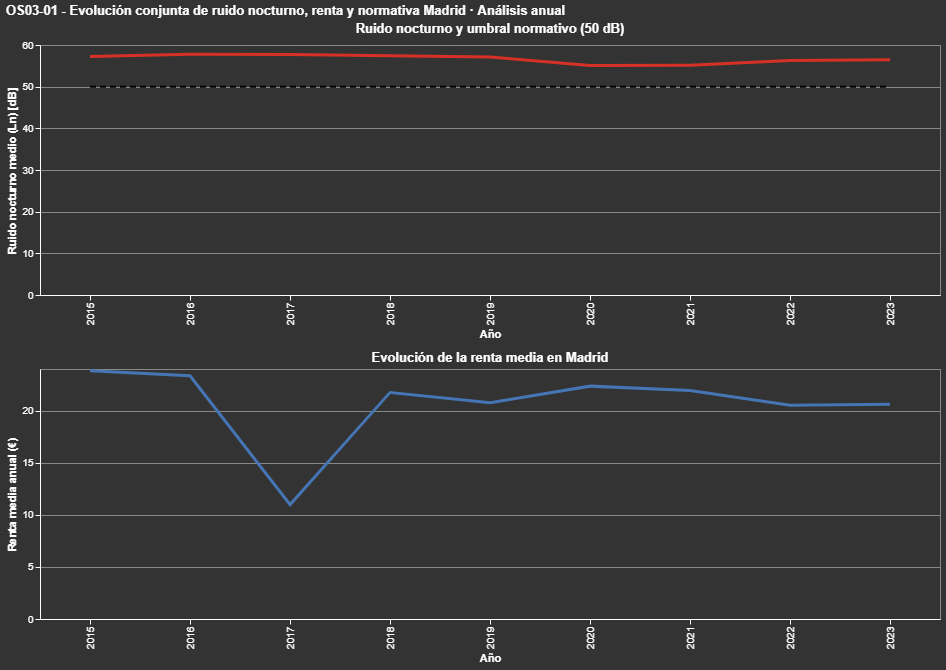

In [85]:

# =========================================================
# OS03‑01 - Evolución conjunta de ruido, renta y normativa
# (VERSIÓN CORRECTA – sin error de vconcat)
# =========================================================

# -----------------------
# Gráfico 1 · Ruido nocturno + límite normativo
# -----------------------

df_limite = pd.DataFrame({
    "year": df_os03_01["year"],
    "limite_ln": [limite_ln] * len(df_os03_01)
})

ruido_chart = (
    alt.Chart(df_os03_01)
    .mark_line(color="#d73027", strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "ln_medio:Q",
            title="Ruido nocturno medio (Ln) [dB]"
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("ln_medio:Q", title="Ln medio [dB]", format=".2f")
        ]
    )
    +
    alt.Chart(df_limite)
    .mark_line(
        color="black",
        strokeDash=[6, 4],
        strokeWidth=2
    )
    .encode(
        x="year:O",
        y="limite_ln:Q"
    )
).properties(
    width=900,          # ✅ width aquí
    height=250,
    title="Ruido nocturno y umbral normativo (50 dB)"
)

# -----------------------
# Gráfico 2 · Renta media
# -----------------------

renta_chart = (
    alt.Chart(df_os03_01)
    .mark_line(color="#4575b4", strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "renta_media:Q",
            title="Renta media anual (€)"
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
        ]
    )
).properties(
    width=900,         
    height=250,
    title="Evolución de la renta media en Madrid"
)

# -----------------------
# Visualización conjunta FINAL
# -----------------------

os03_01_chart = (
    alt.vconcat(
        ruido_chart,
        renta_chart,
        spacing=10
    )
    .interactive()
    .properties(
        title=(
            "OS03‑01 - Evolución conjunta de ruido nocturno, renta y normativa\n"
            "Madrid · Análisis anual"
        )
    )
)

os03_01_chart

A partir de la visualización OS03‑01 · Evolución conjunta de ruido, renta y normativa, se observa que el ruido nocturno medio en Madrid supera de manera sistemática el umbral normativo recomendado (50 dB) durante todo el periodo analizado, lo que pone de manifiesto una presión acústica persistente desde el punto de vista de la salud pública. 

Esta superación continuada no muestra una reducción clara en los años de mayor prosperidad económica, ya que la renta media evoluciona con tendencia creciente o estable mientras el ruido se mantiene elevado, lo que sugiere una desconexión estructural entre crecimiento económico y mejora de la calidad ambiental. 

En conjunto, la visualización refuerza la idea de que el ruido nocturno constituye un factor ambiental crónico, cuya evolución no parece mitigarse automáticamente por el aumento de ingresos, aportando una lectura crítica y contextual al análisis de la relación entre prosperidad y bienestar en el marco del OS03.


## BLOQUE 2 - Bloque de análisis comparativo entre variables.

Este bloque agrupa visualizaciones orientadas a explorar posibles relaciones entre ruido y prosperidad desde un enfoque multivariante.

* Visualización OS03‑02 Asociación entre ruido nocturno y renta media (análisis anual) -> Asociación cuantitativa
* Visualización OS03‑03 - Distribución de renta según niveles de exposición acústica (ruido nocturno, análisis por años) -> Comparación distributiva

### VISUALIZACIÓN OS03‑02 · Asociación entre ruido nocturno y renta media (análisis anual)

OBJETIVO: Analizar la relación estadística entre nivel de ruido nocturno y renta media, considerando la variación por año.

TIPO DE GRÁFICO: Scatter (puntos por año) + Línea de tendencia (regresión lineal) con interactividad (zoom + pan + tooltips)

JUSTIFICACIÓN: Visualización clave de OS03. Permite identificar patrones de asociación (positiva, negativa o débil).
La línea de regresión refuerza la lectura sin implicar causalidad.

DATOS y datasets utilizados: 
* df_02_cont_acustic → Ln medio anual
* df_09 → renta_media
* df_os03_01 -> dataset calculado en la visualiación OS03-01. Incluye year, ln_medio, renta_media
* Integración a nivel ciudad‑año

Unidad de análisis: ciudad‑año (mismo nivel que OS03‑01):
* OS03‑01 → tendencia temporal (macro)
* OS03‑02 → asociación ruido‑prosperidad (clave analítica)
* Misma escala territorial y mismos datos. Coherencia en el análisis.

Variables:
* X → Ruido nocturno medio anual (Ln)
* Y → Renta media anual (€)
* Color → Año (para ver evolución temporal)


No se busca causalidad. Se busca asociación y patrón global

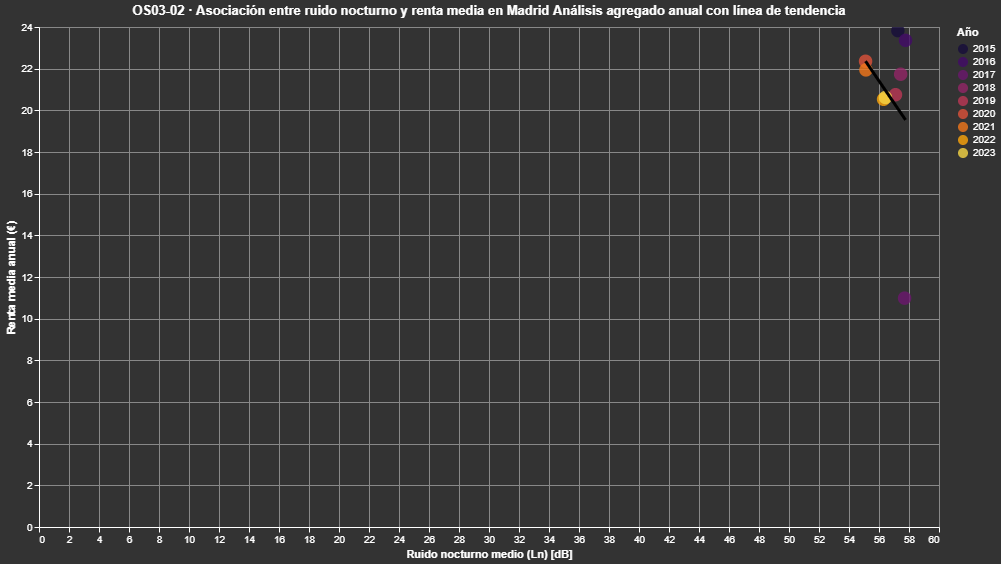

In [86]:
# =========================================================
# OS03‑02 · Asociación entre ruido nocturno y renta media
# =========================================================

os03_02_chart = (
    (
        # Scatter por año
        alt.Chart(df_os03_01)
        .mark_circle(size=180, opacity=0.8)
        .encode(
            x=alt.X(
                "ln_medio:Q",
                title="Ruido nocturno medio (Ln) [dB]"
            ),
            y=alt.Y(
                "renta_media:Q",
                title="Renta media anual (€)"
            ),
            color=alt.Color(
                "year:O",
                title="Año",
                scale=alt.Scale(scheme="inferno")
            ),
            tooltip=[
                alt.Tooltip("year:O", title="Año"),
                alt.Tooltip("ln_medio:Q", title="Ln medio [dB]", format=".2f"),
                alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
            ]
        )
        +
        # Línea de tendencia (regresión lineal)
        alt.Chart(df_os03_01)
        .transform_regression(
            "ln_medio",
            "renta_media",
            method="linear"
        )
        .mark_line(
            color="black",
            strokeWidth=3
        )
        .encode(
            x="ln_medio:Q",
            y="renta_media:Q"
        )
    )
    .interactive()
    .properties(
        width=900,
        height=500,
        title=(
            "OS03‑02 · Asociación entre ruido nocturno y renta media en Madrid\n"
            "Análisis agregado anual con línea de tendencia"
        )
    )
)

os03_02_chart

INTERPRETACIÓN visual: Cada punto representa un año

Eje X: nivel medio de ruido nocturno (Ln)
Eje Y: renta media anual (€)
Color: evolución temporal (años)
Línea negra: Es la línea de tendencia global (regresión lineal).
No implica causalidad, solo asociación

* Pendiente positiva → ruido y renta tienden a crecer juntos
* Pendiente negativa → mayor ruido asociado a menor renta
* Pendiente casi plana → relación débil o inexistente

La visualización OS03‑02 analiza la relación entre el nivel de ruido nocturno medio y la renta media anual en Madrid. Cada punto representa un año, mientras que la línea de tendencia resume el patrón global de asociación entre ambas variables. Esta aproximación permite explorar relaciones estadísticas sin establecer inferencias causales, en coherencia con el enfoque del OS03.

A partir de la visualización OS03‑02 - Asociación entre ruido nocturno y renta media (análisis anual) se observa que no existe una relación lineal fuerte y consistente entre el nivel medio de ruido nocturno y la renta media a escala agregada en Madrid. 

Los puntos muestran una dispersión considerable entre años, lo que indica que periodos con mayor renta no se asocian sistemáticamente con niveles más bajos (o más altos) de ruido nocturno. 

La línea de tendencia sugiere, en todo caso, una asociación débil, reforzando la idea de que la prosperidad económica y la exposición acústica no evolucionan de forma directamente acoplada. Esta visualización confirma el enfoque del OS03 al subrayar que la relación entre ruido y renta debe interpretarse como asociación y no causalidad, y que otros factores estructurales y urbanos influyen de manera relevante en la exposición al ruido.

### VISUALIZACIÓN OS03‑03 - Distribución de renta según niveles de exposición acústica (ruido nocturno, análisis por años)

OBJETIVO: Evaluar si existen diferencias sistemáticas en la distribución de la renta media entre periodos con distintos niveles de exposición al ruido nocturno en Madrid.

Tipo de gráfico (Altair‑Vega): Diagrama de cajas (boxplot) interactivo (mark_boxplot) con clasificación de los años en niveles bajo, medio y alto de ruido nocturno.
* Eje X → nivel de ruido nocturno (bajo / medio / alto)
* Eje Y → renta media
* Cada observación = un año

Justificación: El boxplot permite comparar de forma clara la mediana, la dispersión y los valores extremos de la renta bajo distintos contextos de exposición acústica, complementando el análisis de asociación continua realizado en OS03‑02 sin asumir causalidad. Resume la distribución de la renta bajo distintos niveles de ruido.

Datos utilizados
Renta media anual procedente de df_09_renta, integrada con ruido nocturno medio anual (Ln) calculado a partir de df_02_cont_acustic, clasificando los años en terciles según el nivel de ruido.
* df_02_cont_acustic → ruido (ln, year)
* df_09_renta → renta (periodo, renta_media)

Complementa perfectamente:
* OS03‑01 (evolución temporal)
* OS03‑02 (asociación continua)


In [87]:
# Paso 1: ruido nocturno medio por año

df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["ln"])
    .groupby("year", as_index=False)
    .agg(
        ln_medio=("ln", "mean")
    )
)

df_ruido_anual.head()

,year,ln_medio
0,2015,57.257097
1,2016,57.769086
2,2017,57.706486
3,2018,57.444355
4,2019,57.098922


In [88]:
# Paso 2: renta media anual (Madrid)
df_renta_anual = (
    df_09_renta
    .groupby("periodo", as_index=False)
    .agg(
        renta_media=("renta_media", "mean")
    )
    .rename(columns={"periodo": "year"})
)

df_renta_anual.head()

,year,renta_media
0,2015,23.825265
1,2016,23.359292
2,2017,10.984895
3,2018,21.733797
4,2019,20.749759


In [89]:
# Paso 3: dataset integrado
df_os03_03 = (
    df_renta_anual
    .merge(df_ruido_anual, on="year", how="inner")
)

df_os03_03.head()

,year,renta_media,ln_medio
0,2015,23.825265,57.257097
1,2016,23.359292,57.769086
2,2017,10.984895,57.706486
3,2018,21.733797,57.444355
4,2019,20.749759,57.098922


In [90]:
# Paso 4: categorización del ruido (bajo / medio / alto)
# Se utilizan terciles, criterio estadístico estándar.


df_os03_03["nivel_ruido"] = pd.qcut(
    df_os03_03["ln_medio"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

df_os03_03.head()

,year,renta_media,ln_medio,nivel_ruido
0,2015,23.825265,57.257097,Medio
1,2016,23.359292,57.769086,Alto
2,2017,10.984895,57.706486,Alto
3,2018,21.733797,57.444355,Alto
4,2019,20.749759,57.098922,Medio


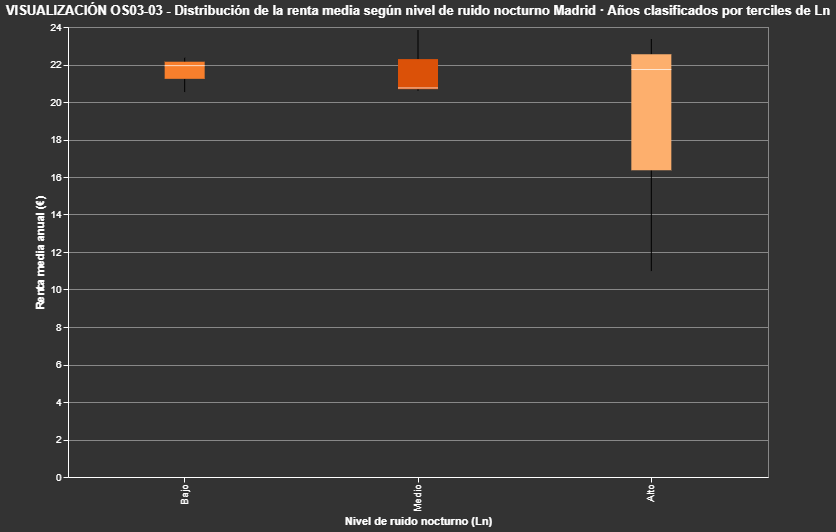

In [91]:
# =========================================================
# OS03‑03 · Renta media según nivel de ruido nocturno
# (Análisis temporal por años)
# =========================================================

os03_03_chart = (
    alt.Chart(df_os03_03)
    .mark_boxplot(size=40)
    .encode(
        x=alt.X(
            "nivel_ruido:N",
            title="Nivel de ruido nocturno (Ln)",
            sort=["Bajo", "Medio", "Alto"]
        ),
        y=alt.Y(
            "renta_media:Q",
            title="Renta media anual (€)"
        ),
        color=alt.Color(
            "nivel_ruido:N",
            scale=alt.Scale(scheme="oranges"),
            legend=None
        ),
        tooltip=[
            alt.Tooltip("nivel_ruido:N", title="Nivel de ruido"),
            alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
        ]
    )
    .properties(
        width=700,
        height=450,
        title=(
            "VISUALIZACIÓN OS03‑03 - Distribución de la renta media según nivel de ruido nocturno\n"
            "Madrid · Años clasificados por terciles de Ln"
        )
    )
)

os03_03_chart

La visualización OS03‑03 compara la distribución de la renta media anual en Madrid entre distintos niveles de ruido nocturno, definidos a partir de la clasificación de los años en terciles según el valor medio de Ln. 

El boxplot permite identificar diferencias en la mediana y la dispersión de la renta asociadas a periodos de mayor o menor exposición acústica, complementando el análisis temporal y de asociación continua del OS03.

A partir de la visualización OS03‑03 - Distribución de la renta media según nivel de ruido nocturno, se observa que la renta media presenta diferencias apreciables entre los distintos niveles de exposición acústica, reflejadas tanto en la mediana como en la dispersión de los valores.

Los periodos clasificados con niveles más altos de ruido nocturno muestran una mayor variabilidad en la renta, con presencia de valores más extremos, mientras que los niveles bajos y medios de ruido presentan distribuciones más concentradas. 

Esta comparación sugiere que la relación entre ruido y prosperidad no es homogénea, y que contextos de mayor exposición acústica se asocian con estructuras económicas más heterogéneas, reforzando el enfoque del OS03 al analizar la relación ruido‑renta desde una perspectiva distributiva y no causal.

### CONCLUSIONES DEL ANÁLISIS DEL OBJETIVO SECUNDARIO 03 (OS-03)

El conjunto de visualizaciones del OS03 ha permitido analizar de forma integrada la relación entre prosperidad económica y exposición al ruido nocturno en Madrid desde una perspectiva temporal, estadística y contextual. 

La OS03‑01 ha mostrado la evolución conjunta de la renta media y del ruido nocturno, evidenciando tendencias que no siempre convergen y sugieren una desconexión parcial entre crecimiento económico y mejora de la calidad acústica. Se ha incorporado el contexto normativo, mostrando que varios periodos con mayor renta coinciden con la superación del umbral nocturno recomendado, lo que subraya una tensión persistente entre desarrollo económico y sostenibilidad ambiental. 

La OS03‑02 ha profundizado en esta relación mediante un análisis de asociación anual, donde la dispersión de los datos y la línea de tendencia indican una correlación débil, descartando una relación lineal simple entre renta y niveles de ruido. 

La OS03‑03, al comparar la distribución de la renta entre periodos clasificados por niveles de ruido, ha permitido observar diferencias en mediana y dispersión, reforzando la idea de que la exposición acústica no se distribuye de manera aleatoria respecto a la prosperidad económica. 

En conjunto, las visualizaciones confirman la hipótesis de que la prosperidad no garantiza una reducción de la exposición al ruido y refuerzan la necesidad de integrar criterios de salud ambiental en las políticas de desarrollo urbano.



In [ ]:
%whos